## Here we calculate the reliability of cortical and cerebellar data in our global model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.evaluation as ev
import cortico_cereb_connectivity.summarize as cs
import Functional_Fusion.atlas_map as am
import SUITPy as suit
import nitools as nt
import nibabel as nb

In [2]:
traindata = gl.traindata_string()
X_img = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cortex.pscalar.nii")
X = X_img.get_fdata()
Y_img = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cerebellum.dscalar.nii")
Y = Y_img.get_fdata()

N, Q = X.shape
_, P = Y.shape

In [3]:
row_axis = Y_img.header.get_axis(0)
half = np.where(
    np.char.endswith(row_axis.name, "half1"), 1,
    np.where(np.char.endswith(row_axis.name, "half2"), 2, np.nan)
)

info = pd.DataFrame({"half": half})

In [4]:
# calculate reliability
R_X, R_vox_X, _, _ = ev.calculate_reliability(X, info)
R_Y, R_vox_Y, _, _ = ev.calculate_reliability(Y, info)

print(f'Mean cortical reliability: {np.nanmean(R_vox_X):.2f} ± {np.nanstd(R_vox_X)/np.sqrt(len(R_vox_X)):.3f} sem')
print(f'Mean cerebellar reliability: {np.nanmean(R_vox_Y):.2f} ± {np.nanstd(R_vox_Y)/np.sqrt(len(R_vox_Y)):.3f} sem')

Mean cortical reliability: 0.78 ± 0.003 sem
Mean cerebellar reliability: 0.74 ± 0.002 sem


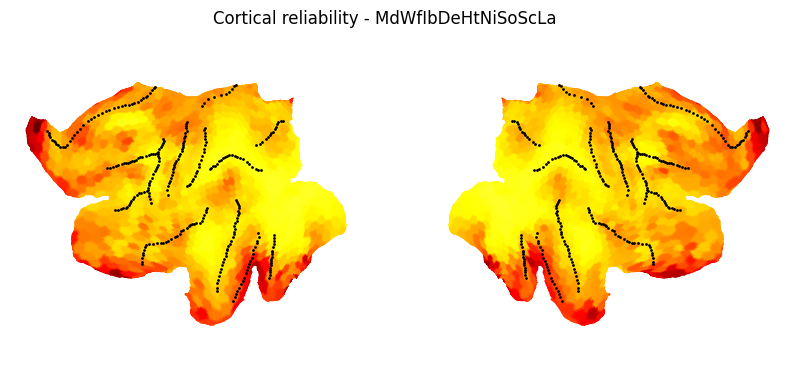

In [8]:
# plot cortical reliability flatmap
from nibabel.cifti2 import cifti2_axes
brain_axis = X_img.header.get_axis(1)
scalar_axis = cifti2_axes.ScalarAxis(["rel"])

new_img = nb.Cifti2Image(
    dataobj=R_vox_X[np.newaxis, :],
    header=nb.Cifti2Header.from_axes((scalar_axis, brain_axis)),
    nifti_header=X_img.nifti_header,
)
rel_X = nt.surf_from_cifti(new_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cs.plot_cortical_flatmap(data=rel_X, axes=axes, cscale=[0, 1.2], cmap='hot')
plt.suptitle(f'Cortical reliability - {traindata}')
plt.show()

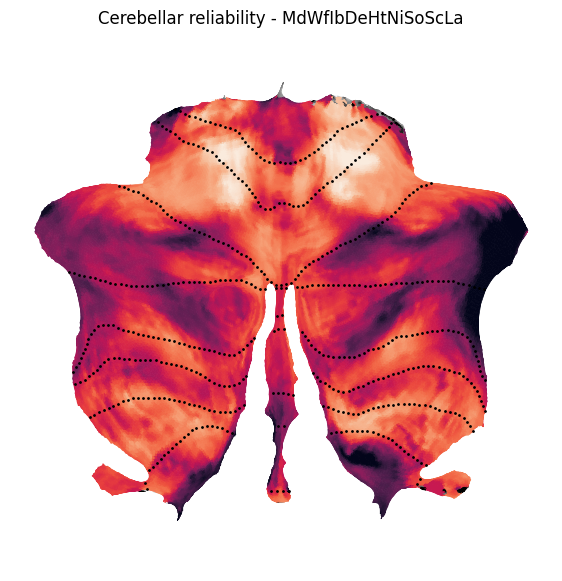

In [11]:
# plot cerebellar reliability flatmap
import seaborn as sns
atlas, _ = am.get_atlas('MNISymC3')
nifti_image = atlas.data_to_nifti(R_vox_Y)
rel_Y = suit.vol_to_surf(nifti_image, space='MNISymC')

suit.flatmap.plot(rel_Y, cmap='rocket', cscale=[0.5, 0.95])
plt.title(f'Cerebellar reliability - {traindata}')
plt.show()